# 05 Model Evaluation

本 Notebook 延續 `04_Model_Development.ipynb` 的輸出結果進行模型評估。

本章原則：

1. **不重新訓練模型**。
2. 只讀取 04 匯出的 metrics、predictions、probabilities 與 confusion matrices。
3. Reproduction 優先依照 Jain et al. (2024) Results 與 Model performance measures。
4. Reproduction 與 Reanalysis 明確分開。

原論文 Evaluation 重點：

- Regression：以 **R² score** 與 **p-value** 為主要評估指標。
- Classification：以 **Precision、Recall、F1-score、Support、Accuracy** 為基本指標。
- 若有 class probability，進一步計算 **AUC、Brier score、ROC curve**。
- DeLong test 需要完整 class probability 與 one-vs-rest ROC，若本地環境或輸出不足，則保留為方法說明。

## 5.1 Evaluation Workflow

```text
04_Model_Development outputs
        ↓
Load exported CSV files
        ↓
Regression Evaluation
  ├─ R²
  ├─ p-value from correlation test
  ├─ RMSE / MAE as supplementary metrics
  ├─ Regression comparison table
  └─ Actual vs Predicted figures
        ↓
Classification Evaluation
  ├─ Accuracy
  ├─ Precision
  ├─ Recall
  ├─ F1-score
  ├─ Macro / weighted average
  ├─ Confusion matrix
  └─ ROC / Brier score if probabilities are available
        ↓
Reproduction Summary
        ↓
Reanalysis
  ├─ Error distribution
  ├─ Residual plot
  ├─ Additional model comparison
  └─ Discussion
```

In [1]:
#--------------------------------------------------
# 5.2 Environment Setup
#--------------------------------------------------

suppressPackageStartupMessages({
  library(tidyverse)
  library(ggplot2)
})

# 若套件不存在，僅標示不可用，不中斷 Notebook
has_pROC <- requireNamespace("pROC", quietly = TRUE)
has_knitr <- requireNamespace("knitr", quietly = TRUE)

set.seed(20240630)

#--------------------------------------------------
# Project path detection
#--------------------------------------------------

candidate_roots <- c("..", ".", "NYCU_R_FinalProject")
project_root <- candidate_roots[dir.exists(file.path(candidate_roots, "output"))][1]

if (is.na(project_root)) {
  project_root <- "."
}

output_path <- file.path(project_root, "output")
figures_path <- file.path(project_root, "figures")

regression_output_path <- file.path(output_path, "Regression")
classification_output_path <- file.path(output_path, "Classification")

dir.create(figures_path, recursive = TRUE, showWarnings = FALSE)
dir.create(file.path(figures_path, "05_Model_Evaluation"), recursive = TRUE, showWarnings = FALSE)

figure_05_path <- file.path(figures_path, "05_Model_Evaluation")

cat("Project root:", project_root, "\n")
cat("Output path:", output_path, "\n")
cat("Figure path:", figure_05_path, "\n")

Project root: .. 
Output path: ../output 
Figure path: ../figures/05_Model_Evaluation 


In [2]:
#--------------------------------------------------
# 5.3 Helper Functions
#--------------------------------------------------

safe_read_csv <- function(path) {
  if (!file.exists(path)) {
    message("File not found: ", path)
    return(tibble())
  }
  readr::read_csv(path, show_col_types = FALSE)
}

save_figure <- function(plot_obj, filename, width = 7, height = 5, dpi = 300) {
  ggsave(
    filename = file.path(figure_05_path, filename),
    plot = plot_obj,
    width = width,
    height = height,
    dpi = dpi
  )
}

calc_regression_metrics <- function(actual, predicted) {
  actual <- as.numeric(actual)
  predicted <- as.numeric(predicted)
  ok <- complete.cases(actual, predicted)
  actual <- actual[ok]
  predicted <- predicted[ok]

  if (length(actual) < 3) {
    return(tibble(R2 = NA_real_, p_value = NA_real_, RMSE = NA_real_, MAE = NA_real_))
  }

  correlation_test <- suppressWarnings(cor.test(actual, predicted))
  r_value <- as.numeric(correlation_test$estimate)

  tibble(
    R2 = r_value^2,
    p_value = correlation_test$p.value,
    RMSE = sqrt(mean((actual - predicted)^2)),
    MAE = mean(abs(actual - predicted))
  )
}

classification_report <- function(truth, prediction) {
  truth <- factor(truth)
  prediction <- factor(prediction, levels = levels(truth))
  classes <- levels(truth)

  report <- map_dfr(classes, function(cls) {
    tp <- sum(truth == cls & prediction == cls, na.rm = TRUE)
    fp <- sum(truth != cls & prediction == cls, na.rm = TRUE)
    fn <- sum(truth == cls & prediction != cls, na.rm = TRUE)
    support <- sum(truth == cls, na.rm = TRUE)

    precision <- ifelse((tp + fp) == 0, NA_real_, tp / (tp + fp))
    recall <- ifelse((tp + fn) == 0, NA_real_, tp / (tp + fn))
    f1 <- ifelse(is.na(precision + recall) || (precision + recall) == 0,
                 NA_real_,
                 2 * precision * recall / (precision + recall))

    tibble(
      Class = cls,
      Precision = precision,
      Recall = recall,
      F1_score = f1,
      Support = support
    )
  })

  accuracy <- mean(truth == prediction, na.rm = TRUE)

  macro_avg <- report %>%
    summarise(
      Class = "Macro avg",
      Precision = mean(Precision, na.rm = TRUE),
      Recall = mean(Recall, na.rm = TRUE),
      F1_score = mean(F1_score, na.rm = TRUE),
      Support = sum(Support)
    )

  weighted_avg <- report %>%
    summarise(
      Class = "Weighted avg",
      Precision = weighted.mean(Precision, Support, na.rm = TRUE),
      Recall = weighted.mean(Recall, Support, na.rm = TRUE),
      F1_score = weighted.mean(F1_score, Support, na.rm = TRUE),
      Support = sum(Support)
    )

  bind_rows(report, macro_avg, weighted_avg) %>%
    mutate(Accuracy = accuracy)
}

calc_brier_multiclass <- function(prob_df, truth_col = "Truth") {
  if (!truth_col %in% names(prob_df)) {
    return(NA_real_)
  }

  prob_cols <- names(prob_df)[str_detect(names(prob_df), "^Prob_Class_")]
  if (length(prob_cols) == 0) {
    return(NA_real_)
  }

  truth <- as.character(prob_df[[truth_col]])
  class_labels <- c("1", "2", "3", "4-6", ">6")
  if (length(prob_cols) != length(class_labels)) {
    class_labels <- as.character(seq_along(prob_cols))
  }

  prob_matrix <- as.matrix(prob_df[, prob_cols])
  indicator_matrix <- sapply(class_labels, function(cls) as.numeric(truth == cls))

  mean(rowSums((prob_matrix - indicator_matrix)^2, na.rm = TRUE), na.rm = TRUE)
}

## 5.4 Load Model Outputs from 04

本節讀取 04 最後匯出的檔案。若尚未執行 04 的 `4.9 Export Model Outputs`，請先回到 04 執行最後輸出區塊。

In [3]:
#--------------------------------------------------
# 5.4 Load exported outputs
#--------------------------------------------------

regression_metrics_raw <- safe_read_csv(file.path(regression_output_path, "Regression_metrics.csv"))
regression_predictions <- safe_read_csv(file.path(regression_output_path, "Regression_predictions_all.csv"))

classification_metrics_raw <- safe_read_csv(file.path(classification_output_path, "Classification_metrics.csv"))
classification_predictions <- safe_read_csv(file.path(classification_output_path, "Classification_predictions_all.csv"))
classification_probabilities <- safe_read_csv(file.path(classification_output_path, "Classification_probabilities_all.csv"))

export_log <- safe_read_csv(file.path(output_path, "04_export_log.csv"))

export_log

File not found: ../output/Classification/Classification_probabilities_all.csv



Output,Status,Folder
<chr>,<chr>,<chr>
Regression metrics,Exported,/Users/pingl_macstudio_ai-lab/Desktop/NYCU_R_FinalProject/output/Regression
Regression predictions,Exported,/Users/pingl_macstudio_ai-lab/Desktop/NYCU_R_FinalProject/output/Regression
Classification metrics,Exported,/Users/pingl_macstudio_ai-lab/Desktop/NYCU_R_FinalProject/output/Classification
Classification predictions,Exported,/Users/pingl_macstudio_ai-lab/Desktop/NYCU_R_FinalProject/output/Classification
Classification probabilities,Not available,/Users/pingl_macstudio_ai-lab/Desktop/NYCU_R_FinalProject/output/Classification
Confusion matrices,Exported,/Users/pingl_macstudio_ai-lab/Desktop/NYCU_R_FinalProject/output/Classification


## 5.5 Reproduction Part I: Regression Evaluation

原論文 Table 6 與 Table 7 使用 **R² score** 與 **p-value** 比較三種 regression models。

本重現版本：

- 以 04 輸出的 Actual 與 Predicted 重新計算 R² 與 p-value。
- RMSE 與 MAE 作為補充指標，因為原論文主表未列出 RMSE / MAE。
- CatBoost Regression 因 R 4.6.1 Apple Silicon 環境限制標示為 `Not run`。

In [4]:
#--------------------------------------------------
# 5.5.1 Recalculate regression metrics from predictions
#--------------------------------------------------

regression_eval_table <- regression_predictions %>%
  group_by(Dataset, Model) %>%
  summarise(
    calc_regression_metrics(Actual, Predicted),
    .groups = "drop"
  ) %>%
  arrange(Dataset, desc(R2))

regression_eval_table

Dataset,Model,R2,p_value,RMSE,MAE
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
Newborn,Random Forest Regression - Target,0.7455641,0,3.623603,1.253503
Newborn,Linear Regression - One Hot,0.5559621,0,4.919452,1.705203
Non-newborn,Random Forest Regression - Target,0.3999885,0,5.677854,2.820428
Non-newborn,Linear Regression - One Hot,0.3301282,0,6.009947,3.032439


In [5]:
#--------------------------------------------------
# 5.5.2 Jain et al. Table 6 and Table 7 reference values
#--------------------------------------------------

jain_regression_reference <- tibble(
  Dataset = c(
    "Non-newborn", "Non-newborn", "Non-newborn",
    "Newborn", "Newborn", "Newborn"
  ),
  Model = c(
    "Catboost regression",
    "Random Forest Regression",
    "Linear Regression",
    "Catboost regression",
    "Random Forest Regression",
    "Linear Regression"
  ),
  Jain_R2 = c(0.432, 0.396, 0.420, 0.730, 0.767, 0.820),
  Jain_p_value = c("<1e-2", "<1e-2", "<1e-2", "<1e-2", "<1e-2", "<1e-2")
)

jain_regression_reference

Dataset,Model,Jain_R2,Jain_p_value
<chr>,<chr>,<dbl>,<chr>
Non-newborn,Catboost regression,0.432,<1e-2
Non-newborn,Random Forest Regression,0.396,<1e-2
Non-newborn,Linear Regression,0.420,<1e-2
Newborn,Catboost regression,0.730,<1e-2
Newborn,Random Forest Regression,0.767,<1e-2
Newborn,Linear Regression,0.820,<1e-2


In [6]:
#--------------------------------------------------
# 5.5.3 Regression comparison table
#--------------------------------------------------

regression_model_map <- function(model_name) {
  case_when(
    str_detect(model_name, regex("Linear", ignore_case = TRUE)) ~ "Linear Regression",
    str_detect(model_name, regex("Random Forest", ignore_case = TRUE)) ~ "Random Forest Regression",
    str_detect(model_name, regex("CatBoost|Catboost", ignore_case = TRUE)) ~ "Catboost regression",
    TRUE ~ model_name
  )
}

regression_comparison_reproduction <- regression_eval_table %>%
  mutate(Model_for_join = regression_model_map(Model)) %>%
  left_join(
    jain_regression_reference,
    by = c("Dataset", "Model_for_join" = "Model")
  ) %>%
  mutate(
    Difference_from_Jain_R2 = R2 - Jain_R2,
    p_value_display = case_when(
      is.na(p_value) ~ NA_character_,
      p_value < 0.01 ~ "<1e-2",
      TRUE ~ formatC(p_value, format = "e", digits = 2)
    )
  ) %>%
  select(
    Dataset,
    Model,
    R2,
    p_value_display,
    RMSE,
    MAE,
    Jain_R2,
    Jain_p_value,
    Difference_from_Jain_R2
  )

regression_comparison_reproduction

Dataset,Model,R2,p_value_display,RMSE,MAE,Jain_R2,Jain_p_value,Difference_from_Jain_R2
<chr>,<chr>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>
Newborn,Random Forest Regression - Target,0.7455641,<1e-2,3.623603,1.253503,0.767,<1e-2,-0.021435902
Newborn,Linear Regression - One Hot,0.5559621,<1e-2,4.919452,1.705203,0.820,<1e-2,-0.264037921
Non-newborn,Random Forest Regression - Target,0.3999885,<1e-2,5.677854,2.820428,0.396,<1e-2,0.003988545
Non-newborn,Linear Regression - One Hot,0.3301282,<1e-2,6.009947,3.032439,0.420,<1e-2,-0.089871820


In [7]:
#--------------------------------------------------
# 5.5.4 Export regression evaluation table
#--------------------------------------------------

write.csv(
  regression_comparison_reproduction,
  file.path(output_path, "05_regression_evaluation_reproduction.csv"),
  row.names = FALSE
)

## 5.6 Regression Figures

對應原論文 Figure 16、Figure 17、Figure 18：

- Actual Length of Stay vs Predicted Length of Stay scatter plot
- Exact line：理想情況下 Predicted = Actual
- Best fit line：本重現結果的線性趨勢

In [8]:
#--------------------------------------------------
# 5.6.1 Regression scatter plot function
#--------------------------------------------------

plot_regression_scatter <- function(data, dataset_name, model_name) {
  plot_df <- data %>%
    filter(Dataset == dataset_name, Model == model_name) %>%
    filter(!is.na(Actual), !is.na(Predicted))

  if (nrow(plot_df) == 0) {
    message("No data for ", dataset_name, " - ", model_name)
    return(NULL)
  }

  r2_value <- calc_regression_metrics(plot_df$Actual, plot_df$Predicted)$R2

  p <- ggplot(plot_df, aes(x = Actual, y = Predicted)) +
    geom_point(alpha = 0.25, size = 0.6) +
    geom_abline(intercept = 0, slope = 1, linewidth = 0.8) +
    geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
    labs(
      title = paste0("Scatter Plot for Linear Regression (", dataset_name, ")"),
      subtitle = paste0("Model: ", model_name, "; R² = ", round(r2_value, 3)),
      x = "Actual Length of Stay",
      y = "Predicted Length of Stay"
    ) +
    coord_cartesian(xlim = c(0, 120), ylim = c(0, 120)) +
    theme_minimal(base_size = 12)

  return(p)
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


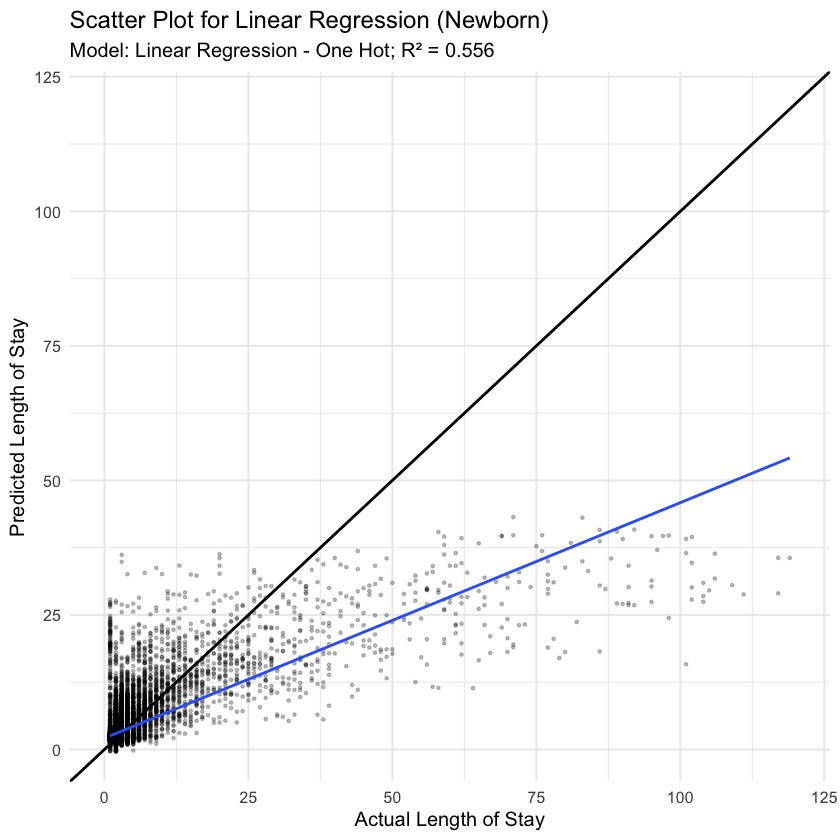

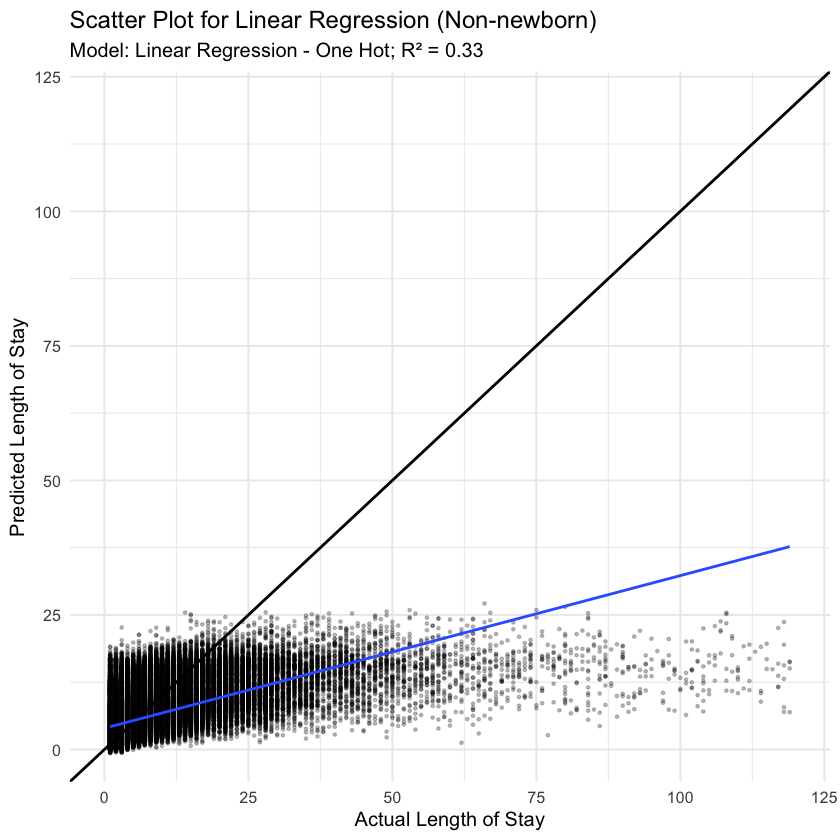

In [9]:
#--------------------------------------------------
# 5.6.2 Generate regression scatter plots
#--------------------------------------------------

linear_models_available <- regression_predictions %>%
  filter(str_detect(Model, regex("Linear", ignore_case = TRUE))) %>%
  distinct(Dataset, Model)

regression_scatter_plots <- list()

for (i in seq_len(nrow(linear_models_available))) {
  dataset_i <- linear_models_available$Dataset[i]
  model_i <- linear_models_available$Model[i]
  plot_i <- plot_regression_scatter(regression_predictions, dataset_i, model_i)

  if (!is.null(plot_i)) {
    print(plot_i)
    filename_i <- paste0(
      "Figure_regression_scatter_",
      str_replace_all(str_to_lower(dataset_i), "[^a-z0-9]+", "_"),
      ".png"
    )
    save_figure(plot_i, filename_i, width = 7, height = 5, dpi = 300)
  }
}

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


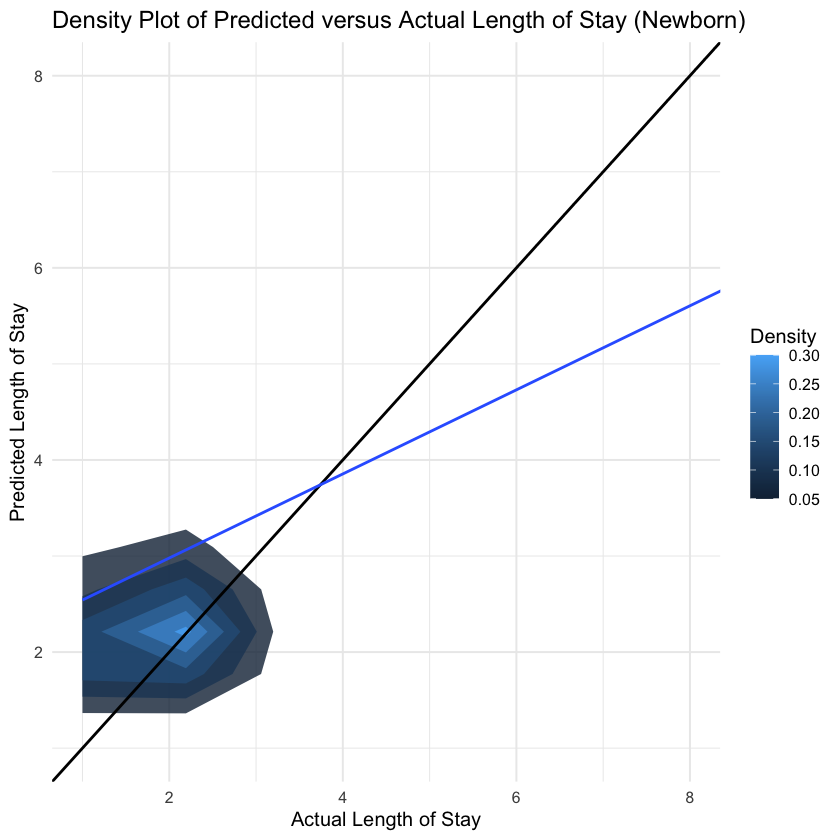

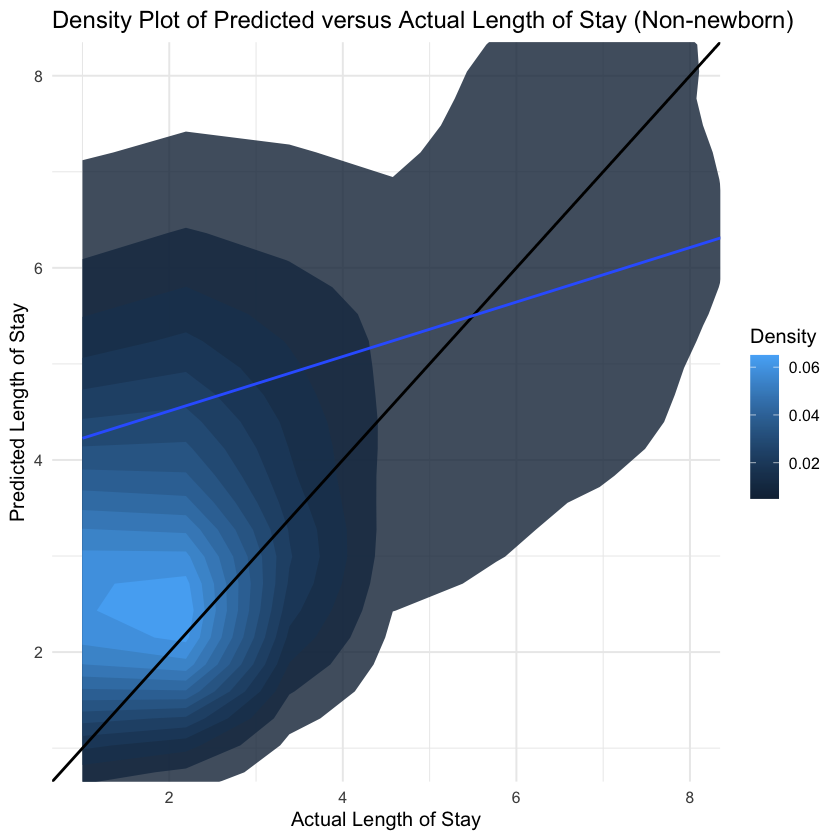

In [10]:
#--------------------------------------------------
# 5.6.3 Actual vs predicted density plot
#--------------------------------------------------

plot_regression_density <- function(data, dataset_name, model_name) {
  plot_df <- data %>%
    filter(Dataset == dataset_name, Model == model_name) %>%
    filter(!is.na(Actual), !is.na(Predicted))

  if (nrow(plot_df) == 0) {
    return(NULL)
  }

  p <- ggplot(plot_df, aes(x = Actual, y = Predicted)) +
    stat_density_2d(aes(fill = after_stat(level)), geom = "polygon", alpha = 0.8) +
    geom_abline(intercept = 0, slope = 1, linewidth = 0.8) +
    geom_smooth(method = "lm", se = FALSE, linewidth = 0.8) +
    labs(
      title = paste0("Density Plot of Predicted versus Actual Length of Stay (", dataset_name, ")"),
      x = "Actual Length of Stay",
      y = "Predicted Length of Stay",
      fill = "Density"
    ) +
    coord_cartesian(xlim = c(1, 8), ylim = c(1, 8)) +
    theme_minimal(base_size = 12)

  return(p)
}

for (i in seq_len(nrow(linear_models_available))) {
  dataset_i <- linear_models_available$Dataset[i]
  model_i <- linear_models_available$Model[i]
  plot_i <- plot_regression_density(regression_predictions, dataset_i, model_i)

  if (!is.null(plot_i)) {
    print(plot_i)
    filename_i <- paste0(
      "Figure_regression_density_",
      str_replace_all(str_to_lower(dataset_i), "[^a-z0-9]+", "_"),
      ".png"
    )
    save_figure(plot_i, filename_i, width = 7, height = 5, dpi = 300)
  }
}

## 5.7 Reproduction Part II: Classification Evaluation

原論文 Table 8 呈現 non-newborn logistic regression 的 multiclass classification report：

- Precision
- Recall
- F1-score
- Support
- Macro average
- Weighted average
- Overall accuracy

本節依 04 匯出的 `Truth` 與 `Prediction` 重新計算相同指標。

In [11]:
#--------------------------------------------------
# 5.7.1 Classification report for all available models
#--------------------------------------------------

classification_eval_table <- classification_predictions %>%
  group_by(Dataset, Model) %>%
  group_modify(~ classification_report(.x$Truth, .x$Prediction)) %>%
  ungroup()

classification_eval_table

Dataset,Model,Class,Precision,Recall,F1_score,Support,Accuracy
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>
Newborn,Random Forest Classifier - Target,>6,0.6960717,0.79091621,0.74046921,1277,0.5922500
Newborn,Random Forest Classifier - Target,1,0.6749226,0.15117892,0.24702550,1442,0.5922500
Newborn,Random Forest Classifier - Target,2,0.5989264,0.95360195,0.73575130,10647,0.5922500
Newborn,Random Forest Classifier - Target,3,0.3750000,0.07819181,0.12940185,4911,0.5922500
Newborn,Random Forest Classifier - Target,4-6,0.3200000,0.04643064,0.08109478,1723,0.5922500
Newborn,Random Forest Classifier - Target,Macro avg,0.5329841,0.40406391,0.38674853,20000,0.5922500
Newborn,Random Forest Classifier - Target,Weighted avg,0.5315938,0.59225000,0.49552764,20000,0.5922500
Non-newborn,Random Forest Classifier - Target,>6,0.6257436,0.66985092,0.64704649,6909,0.4530333
Non-newborn,Random Forest Classifier - Target,1,0.4366142,0.47504819,0.45502103,4669,0.4530333


In [12]:
#--------------------------------------------------
# 5.7.2 Extract logistic regression table corresponding to Jain Table 8
#--------------------------------------------------

classification_table8_reproduction <- classification_eval_table %>%
  filter(
    Dataset == "Non-newborn",
    str_detect(Model, regex("Multinomial Logistic", ignore_case = TRUE))
  ) %>%
  mutate(
    across(c(Precision, Recall, F1_score, Accuracy), ~ round(.x, 3))
  )

classification_table8_reproduction

Dataset,Model,Class,Precision,Recall,F1_score,Support,Accuracy
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<int>,<dbl>


In [13]:
#--------------------------------------------------
# 5.7.3 Classification model summary
#--------------------------------------------------

classification_model_summary <- classification_eval_table %>%
  filter(Class == "Macro avg") %>%
  transmute(
    Dataset,
    Model,
    Accuracy = Accuracy,
    Macro_Precision = Precision,
    Macro_Recall = Recall,
    Macro_F1 = F1_score,
    Support
  ) %>%
  arrange(Dataset, desc(Macro_F1))

classification_model_summary

Dataset,Model,Accuracy,Macro_Precision,Macro_Recall,Macro_F1,Support
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
Newborn,Random Forest Classifier - Target,0.5922500,0.5329841,0.4040639,0.3867485,20000
Non-newborn,Random Forest Classifier - Target,0.4530333,0.4738705,0.4358677,0.4218749,30000


In [14]:
#--------------------------------------------------
# 5.7.4 Export classification evaluation tables
#--------------------------------------------------

write.csv(
  classification_eval_table,
  file.path(output_path, "05_classification_report_all_models.csv"),
  row.names = FALSE
)

write.csv(
  classification_model_summary,
  file.path(output_path, "05_classification_model_summary.csv"),
  row.names = FALSE
)

## 5.8 Confusion Matrix

對應原論文 Figure 12 與 Figure 13：

- Figure 12：Non-newborn classification confusion matrix
- Figure 13：Newborn classification confusion matrix

本節會依每個可用模型產生 confusion matrix heatmap。

In [15]:
#--------------------------------------------------
# 5.8.1 Confusion matrix plot function
#--------------------------------------------------

plot_confusion_matrix <- function(data, dataset_name, model_name) {
  plot_df <- data %>%
    filter(Dataset == dataset_name, Model == model_name) %>%
    filter(!is.na(Truth), !is.na(Prediction)) %>%
    mutate(
      Truth = factor(Truth, levels = c("1", "2", "3", "4-6", ">6")),
      Prediction = factor(Prediction, levels = c("1", "2", "3", "4-6", ">6"))
    ) %>%
    count(Truth, Prediction, name = "Count")

  if (nrow(plot_df) == 0) {
    return(NULL)
  }

  p <- ggplot(plot_df, aes(x = Prediction, y = Truth, fill = Count)) +
    geom_tile() +
    geom_text(aes(label = Count), size = 3) +
    labs(
      title = paste0("Confusion Matrix for Classification of ", dataset_name),
      subtitle = model_name,
      x = "Predicted Class",
      y = "Actual Class",
      fill = "Count"
    ) +
    theme_minimal(base_size = 12) +
    theme(
      panel.grid = element_blank()
    )

  return(p)
}

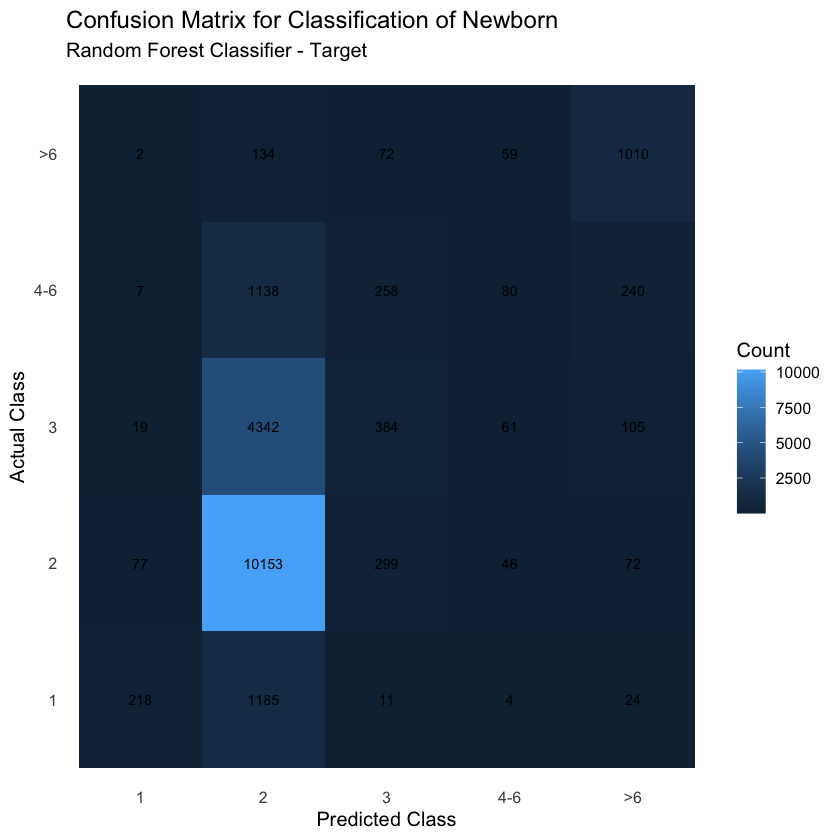

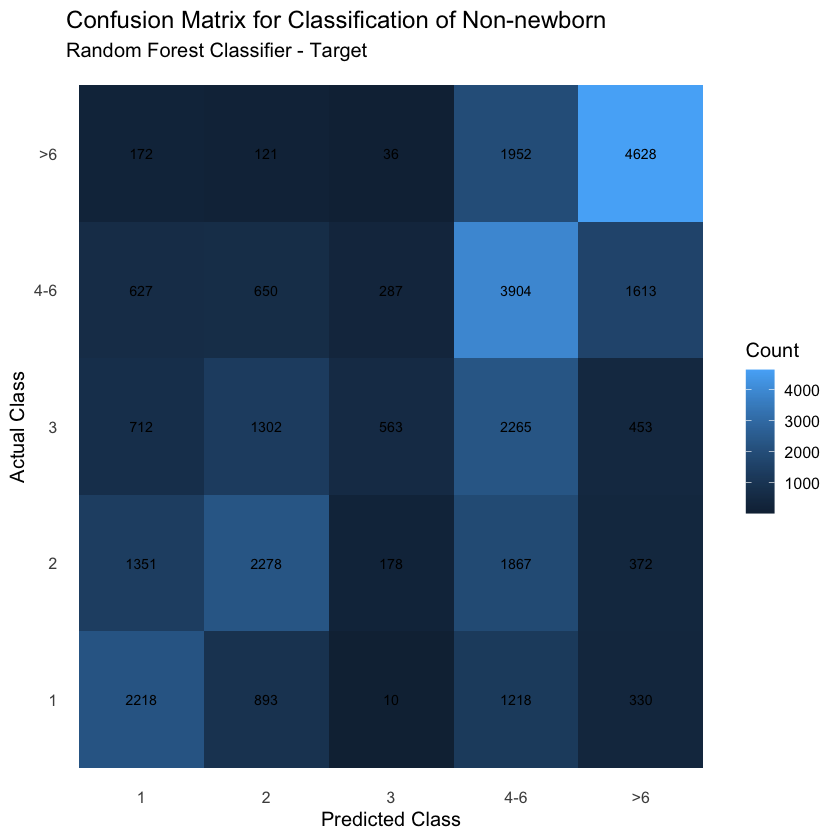

In [16]:
#--------------------------------------------------
# 5.8.2 Generate confusion matrices
#--------------------------------------------------

classification_models_available <- classification_predictions %>%
  distinct(Dataset, Model)

for (i in seq_len(nrow(classification_models_available))) {
  dataset_i <- classification_models_available$Dataset[i]
  model_i <- classification_models_available$Model[i]

  plot_i <- plot_confusion_matrix(classification_predictions, dataset_i, model_i)

  if (!is.null(plot_i)) {
    print(plot_i)
    filename_i <- paste0(
      "Figure_confusion_matrix_",
      str_replace_all(str_to_lower(dataset_i), "[^a-z0-9]+", "_"),
      "_",
      str_replace_all(str_to_lower(model_i), "[^a-z0-9]+", "_"),
      ".png"
    )
    save_figure(plot_i, filename_i, width = 6.5, height = 5.5, dpi = 300)
  }
}

## 5.9 Probability-based Evaluation

本節只有在 04 有輸出 class probability 時執行。

可支援：

- Multiclass Brier score
- One-vs-rest ROC curve
- Average AUC

限制：

- 若 Random Forest / CatBoost probability 未輸出，則無法完整重現原論文 Tables 10–15。
- DeLong test 需要 pairwise ROC objects，若機率不足，本章僅保留方法說明。

In [17]:
#--------------------------------------------------
# 5.9.1 Brier score
#--------------------------------------------------

if (nrow(classification_probabilities) > 0) {
  brier_table <- classification_probabilities %>%
    group_by(Dataset, Model) %>%
    group_modify(~ tibble(Brier_score = calc_brier_multiclass(.x))) %>%
    ungroup() %>%
    arrange(Dataset, Brier_score)
} else {
  brier_table <- tibble(
    Dataset = character(),
    Model = character(),
    Brier_score = numeric()
  )
}

brier_table

Dataset,Model,Brier_score
<chr>,<chr>,<dbl>


In [18]:
#--------------------------------------------------
# 5.9.2 ROC and AUC for one-vs-rest classification
#--------------------------------------------------

compute_auc_table <- function(prob_data) {
  if (!has_pROC || nrow(prob_data) == 0) {
    return(tibble())
  }

  prob_cols <- names(prob_data)[str_detect(names(prob_data), "^Prob_Class_")]
  class_labels <- c("1", "2", "3", "4-6", ">6")

  if (length(prob_cols) != length(class_labels)) {
    class_labels <- as.character(seq_along(prob_cols))
  }

  map_dfr(seq_along(prob_cols), function(i) {
    truth_binary <- as.numeric(as.character(prob_data$Truth) == class_labels[i])
    score <- prob_data[[prob_cols[i]]]

    if (length(unique(truth_binary)) < 2) {
      auc_value <- NA_real_
    } else {
      roc_obj <- pROC::roc(truth_binary, score, quiet = TRUE)
      auc_value <- as.numeric(pROC::auc(roc_obj))
    }

    tibble(
      Class = class_labels[i],
      AUC = auc_value
    )
  })
}

if (nrow(classification_probabilities) > 0 && has_pROC) {
  auc_table <- classification_probabilities %>%
    group_by(Dataset, Model) %>%
    group_modify(~ compute_auc_table(.x)) %>%
    ungroup() %>%
    group_by(Dataset, Model) %>%
    mutate(Average_AUC = mean(AUC, na.rm = TRUE)) %>%
    ungroup()
} else {
  auc_table <- tibble()
}

auc_table

<0 x 0 matrix>

In [19]:
#--------------------------------------------------
# 5.9.3 ROC curve plot function
#--------------------------------------------------

plot_multiclass_roc <- function(prob_data, dataset_name, model_name) {
  if (!has_pROC || nrow(prob_data) == 0) {
    message("pROC not available or probability data is empty.")
    return(NULL)
  }

  plot_df <- prob_data %>%
    filter(Dataset == dataset_name, Model == model_name)

  if (nrow(plot_df) == 0) {
    return(NULL)
  }

  prob_cols <- names(plot_df)[str_detect(names(plot_df), "^Prob_Class_")]
  class_labels <- c("1", "2", "3", "4-6", ">6")

  if (length(prob_cols) != length(class_labels)) {
    class_labels <- as.character(seq_along(prob_cols))
  }

  roc_df <- map_dfr(seq_along(prob_cols), function(i) {
    truth_binary <- as.numeric(as.character(plot_df$Truth) == class_labels[i])
    score <- plot_df[[prob_cols[i]]]

    if (length(unique(truth_binary)) < 2) {
      return(tibble())
    }

    roc_obj <- pROC::roc(truth_binary, score, quiet = TRUE)
    tibble(
      FPR = 1 - roc_obj$specificities,
      TPR = roc_obj$sensitivities,
      Class = paste0("Class ", class_labels[i], " vs Rest"),
      AUC = as.numeric(pROC::auc(roc_obj))
    )
  })

  if (nrow(roc_df) == 0) {
    return(NULL)
  }

  avg_auc <- roc_df %>%
    distinct(Class, AUC) %>%
    summarise(Average_AUC = mean(AUC, na.rm = TRUE)) %>%
    pull(Average_AUC)

  p <- ggplot(roc_df, aes(x = FPR, y = TPR, linetype = Class)) +
    geom_line(linewidth = 0.8) +
    geom_abline(intercept = 0, slope = 1, linetype = "dotted") +
    labs(
      title = "Multiclass ROC Curve",
      subtitle = paste0(dataset_name, " - ", model_name, "; Average AUC = ", round(avg_auc, 4)),
      x = "False Positive Rate",
      y = "True Positive Rate",
      linetype = "Class"
    ) +
    theme_minimal(base_size = 12)

  return(p)
}

In [20]:
#--------------------------------------------------
# 5.9.4 Generate ROC curves if probabilities are available
#--------------------------------------------------

if (nrow(classification_probabilities) > 0 && has_pROC) {
  probability_models_available <- classification_probabilities %>%
    distinct(Dataset, Model)

  for (i in seq_len(nrow(probability_models_available))) {
    dataset_i <- probability_models_available$Dataset[i]
    model_i <- probability_models_available$Model[i]

    plot_i <- plot_multiclass_roc(classification_probabilities, dataset_i, model_i)

    if (!is.null(plot_i)) {
      print(plot_i)
      filename_i <- paste0(
        "Figure_ROC_",
        str_replace_all(str_to_lower(dataset_i), "[^a-z0-9]+", "_"),
        "_",
        str_replace_all(str_to_lower(model_i), "[^a-z0-9]+", "_"),
        ".png"
      )
      save_figure(plot_i, filename_i, width = 7, height = 5, dpi = 300)
    }
  }
} else {
  message("ROC curves skipped because probability outputs or pROC package are not available.")
}

ROC curves skipped because probability outputs or pROC package are not available.



In [21]:
#--------------------------------------------------
# 5.9.5 Export probability-based evaluation tables
#--------------------------------------------------

if (nrow(brier_table) > 0) {
  write.csv(
    brier_table,
    file.path(output_path, "05_brier_score_table.csv"),
    row.names = FALSE
  )
}

if (exists("auc_table") && nrow(auc_table) > 0) {
  write.csv(
    auc_table,
    file.path(output_path, "05_auc_table.csv"),
    row.names = FALSE
  )
}

## 5.10 Reproduction Summary

本節彙整 05 的 Reproduction 結果，並標示與 Jain et al. (2024) 可直接對應的項目。

In [22]:
#--------------------------------------------------
# 5.10 Reproduction summary
#--------------------------------------------------

reproduction_summary <- tibble(
  Item = c(
    "Regression R2 and p-value",
    "Regression comparison table",
    "Regression scatter plot",
    "Regression density plot",
    "Classification report",
    "Confusion matrix",
    "Brier score",
    "ROC / AUC",
    "DeLong test"
  ),
  Jain_reference = c(
    "Table 6 and Table 7",
    "Table 6 and Table 7",
    "Figure 16 and Figure 17",
    "Figure 18",
    "Table 8",
    "Figure 12 and Figure 13",
    "Table 14 and Table 15",
    "Figure 23, Figure 24, Figure 25, Table 10, Table 11",
    "Table 12 and Table 13"
  ),
  Status = c(
    ifelse(nrow(regression_eval_table) > 0, "Completed", "Not available"),
    ifelse(nrow(regression_comparison_reproduction) > 0, "Completed", "Not available"),
    ifelse(nrow(linear_models_available) > 0, "Completed", "Not available"),
    ifelse(nrow(linear_models_available) > 0, "Completed", "Not available"),
    ifelse(nrow(classification_eval_table) > 0, "Completed", "Not available"),
    ifelse(nrow(classification_predictions) > 0, "Completed", "Not available"),
    ifelse(nrow(brier_table) > 0, "Completed if probability available", "Skipped: probability not available"),
    ifelse(exists("auc_table") && nrow(auc_table) > 0, "Completed if probability available", "Skipped: probability or pROC not available"),
    "Method described; not required unless full probability outputs are available"
  )
)

write.csv(
  reproduction_summary,
  file.path(output_path, "05_reproduction_summary.csv"),
  row.names = FALSE
)

reproduction_summary

Item,Jain_reference,Status
<chr>,<chr>,<chr>
Regression R2 and p-value,Table 6 and Table 7,Completed
Regression comparison table,Table 6 and Table 7,Completed
Regression scatter plot,Figure 16 and Figure 17,Completed
Regression density plot,Figure 18,Completed
Classification report,Table 8,Completed
Confusion matrix,Figure 12 and Figure 13,Completed
Brier score,Table 14 and Table 15,Skipped: probability not available
ROC / AUC,"Figure 23, Figure 24, Figure 25, Table 10, Table 11",Skipped: probability or pROC not available
DeLong test,Table 12 and Table 13,Method described; not required unless full probability outputs are available


# Reanalysis

以下為 Reanalysis，與前面的 Reproduction 分開。目的不是取代原論文結果，而是利用 04 已輸出的 prediction 結果進一步檢查模型誤差型態。

## 5.11 Reanalysis: Regression Error Distribution

本節檢查 regression residual 的分布。Residual 定義為：

```text
Residual = Actual Length of Stay - Predicted Length of Stay
```

若 residual 大於 0，代表模型低估實際住院天數；若 residual 小於 0，代表模型高估實際住院天數。

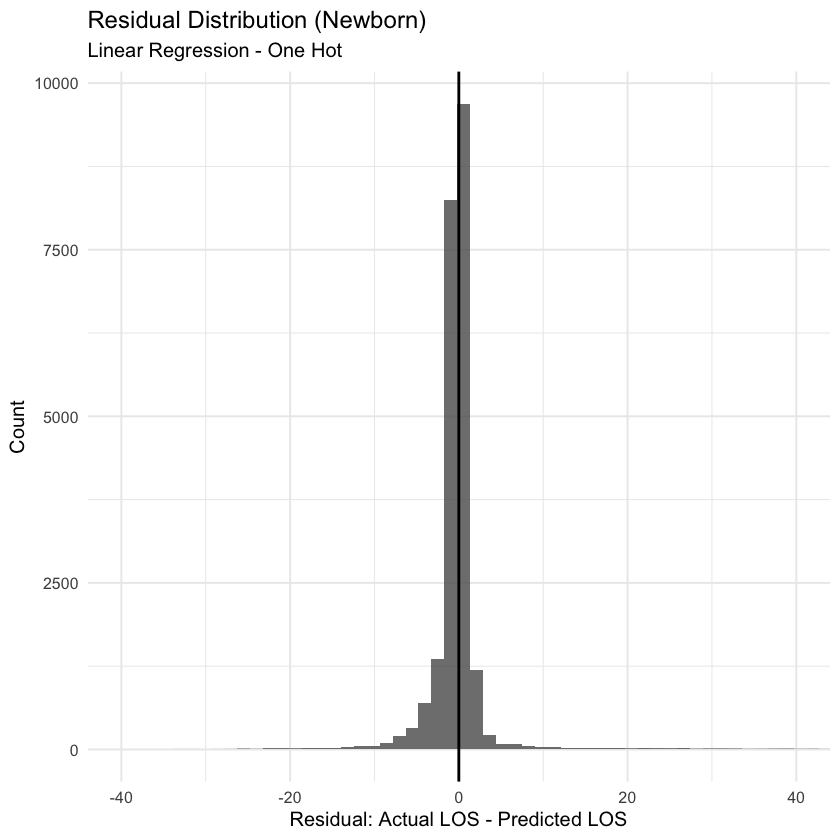

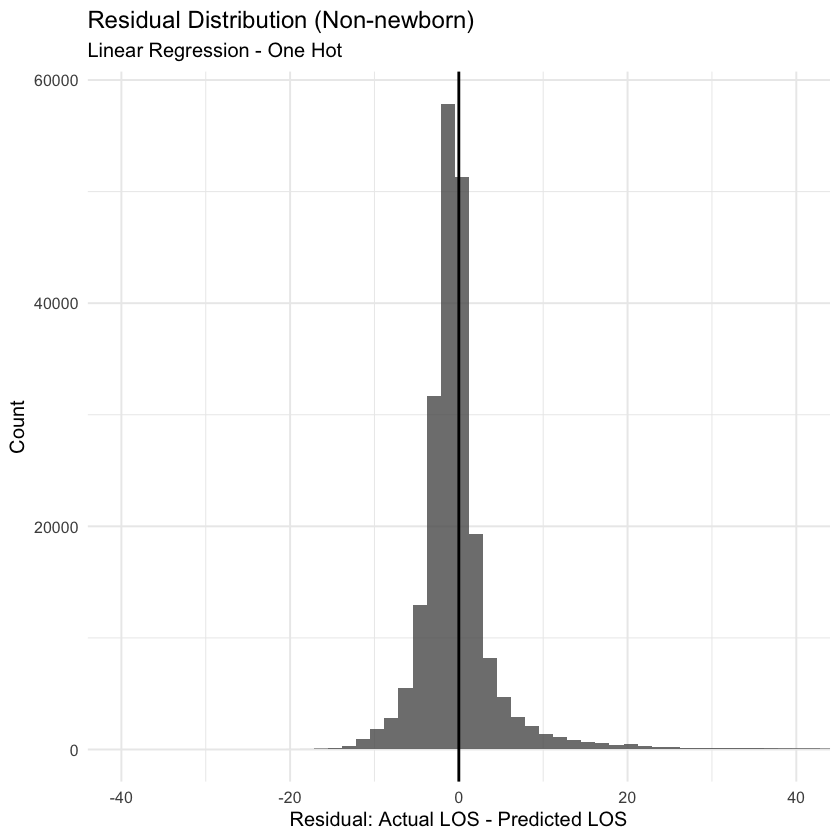

In [23]:
#--------------------------------------------------
# 5.11.1 Residual distribution
#--------------------------------------------------

plot_residual_distribution <- function(data, dataset_name, model_name) {
  plot_df <- data %>%
    filter(Dataset == dataset_name, Model == model_name) %>%
    filter(!is.na(Residual))

  if (nrow(plot_df) == 0) {
    return(NULL)
  }

  p <- ggplot(plot_df, aes(x = Residual)) +
    geom_histogram(bins = 80, alpha = 0.8) +
    geom_vline(xintercept = 0, linewidth = 0.8) +
    labs(
      title = paste0("Residual Distribution (", dataset_name, ")"),
      subtitle = model_name,
      x = "Residual: Actual LOS - Predicted LOS",
      y = "Count"
    ) +
    coord_cartesian(xlim = c(-40, 40)) +
    theme_minimal(base_size = 12)

  return(p)
}

for (i in seq_len(nrow(linear_models_available))) {
  dataset_i <- linear_models_available$Dataset[i]
  model_i <- linear_models_available$Model[i]
  plot_i <- plot_residual_distribution(regression_predictions, dataset_i, model_i)

  if (!is.null(plot_i)) {
    print(plot_i)
    filename_i <- paste0(
      "Reanalysis_residual_distribution_",
      str_replace_all(str_to_lower(dataset_i), "[^a-z0-9]+", "_"),
      ".png"
    )
    save_figure(plot_i, filename_i, width = 7, height = 5, dpi = 300)
  }
}

In [24]:
#--------------------------------------------------
# 5.11.2 Residual summary table
#--------------------------------------------------

residual_summary <- regression_predictions %>%
  group_by(Dataset, Model) %>%
  summarise(
    Mean_residual = mean(Residual, na.rm = TRUE),
    Median_residual = median(Residual, na.rm = TRUE),
    SD_residual = sd(Residual, na.rm = TRUE),
    P25_residual = quantile(Residual, 0.25, na.rm = TRUE),
    P75_residual = quantile(Residual, 0.75, na.rm = TRUE),
    Underestimated_percent = mean(Residual > 0, na.rm = TRUE) * 100,
    Overestimated_percent = mean(Residual < 0, na.rm = TRUE) * 100,
    .groups = "drop"
  )

write.csv(
  residual_summary,
  file.path(output_path, "05_residual_summary.csv"),
  row.names = FALSE
)

residual_summary

Dataset,Model,Mean_residual,Median_residual,SD_residual,P25_residual,P75_residual,Underestimated_percent,Overestimated_percent
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Newborn,Linear Regression - One Hot,-0.040526611,-0.1642305,4.919393,-0.8195970,0.4786812,41.80421,58.19579
Newborn,Random Forest Regression - Target,-0.025339146,-0.3876896,3.623593,-0.4904191,0.5261462,33.04515,66.95485
Non-newborn,Linear Regression - One Hot,0.002215304,-0.7151043,6.009961,-2.2825846,0.8373172,37.04681,62.95319
Non-newborn,Random Forest Regression - Target,-0.003146441,-0.6197043,5.677866,-1.9376015,0.6957311,35.01955,64.98045


## 5.12 Reanalysis: Classification Error Distribution

本節將分類錯誤轉換為 ordinal error，以檢查模型是否主要錯在相鄰類別。

原論文也指出 confusion matrix 中錯誤多發生於相鄰 classes。

In [25]:
#--------------------------------------------------
# 5.12 Classification ordinal error
#--------------------------------------------------

class_to_numeric <- function(x) {
  case_when(
    x == "1" ~ 1,
    x == "2" ~ 2,
    x == "3" ~ 3,
    x == "4-6" ~ 5,
    x == ">6" ~ 8,
    TRUE ~ NA_real_
  )
}

classification_error_distribution <- classification_predictions %>%
  mutate(
    Truth_numeric = class_to_numeric(Truth),
    Prediction_numeric = class_to_numeric(Prediction),
    Absolute_class_error = abs(Truth_numeric - Prediction_numeric)
  ) %>%
  group_by(Dataset, Model, Absolute_class_error) %>%
  summarise(Count = n(), .groups = "drop") %>%
  group_by(Dataset, Model) %>%
  mutate(Percent = Count / sum(Count) * 100) %>%
  ungroup()

classification_error_distribution

Dataset,Model,Absolute_class_error,Count,Percent
<chr>,<chr>,<dbl>,<int>,<dbl>
Newborn,Random Forest Classifier - Target,0,11845,59.225000
Newborn,Random Forest Classifier - Target,1,5903,29.515000
Newborn,Random Forest Classifier - Target,2,349,1.745000
Newborn,Random Forest Classifier - Target,3,1483,7.415000
Newborn,Random Forest Classifier - Target,4,11,0.055000
Newborn,Random Forest Classifier - Target,5,177,0.885000
Newborn,Random Forest Classifier - Target,6,206,1.030000
Newborn,Random Forest Classifier - Target,7,26,0.130000
Non-newborn,Random Forest Classifier - Target,0,13591,45.303333


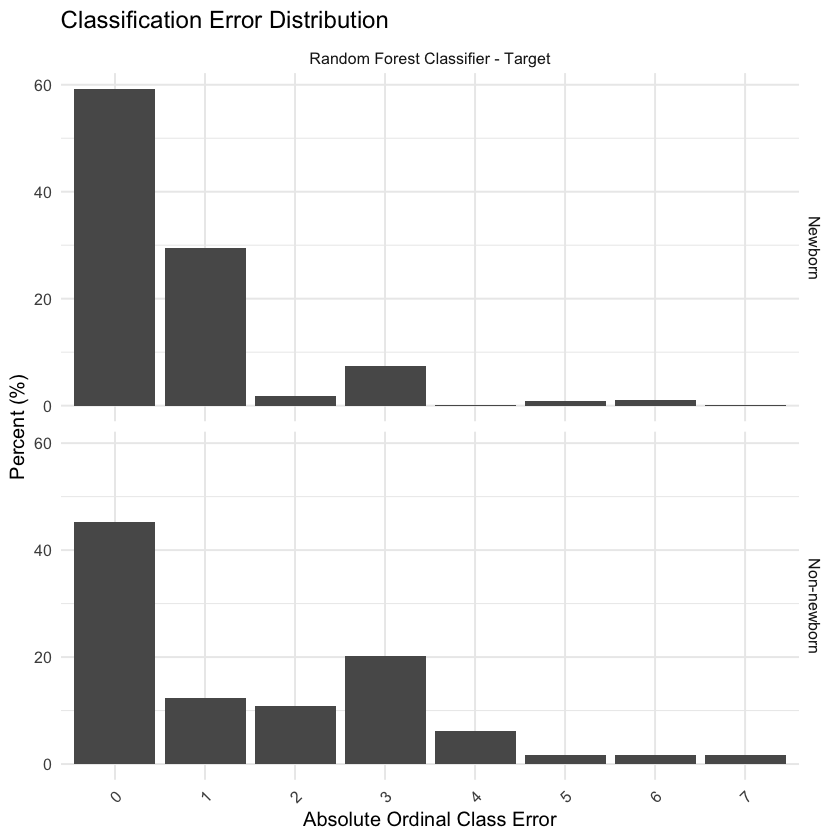

In [26]:
#--------------------------------------------------
# 5.12.2 Plot classification error distribution
#--------------------------------------------------

if (nrow(classification_error_distribution) > 0) {
  p_error <- ggplot(
    classification_error_distribution,
    aes(x = factor(Absolute_class_error), y = Percent)
  ) +
    geom_col() +
    facet_grid(Dataset ~ Model) +
    labs(
      title = "Classification Error Distribution",
      x = "Absolute Ordinal Class Error",
      y = "Percent (%)"
    ) +
    theme_minimal(base_size = 12) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1))

  print(p_error)
  save_figure(p_error, "Reanalysis_classification_error_distribution.png", width = 10, height = 6, dpi = 300)
}

write.csv(
  classification_error_distribution,
  file.path(output_path, "05_classification_error_distribution.csv"),
  row.names = FALSE
)

## 5.13 Final Evaluation Summary

本章完成 04 輸出結果之模型評估。

Reproduction 完成項目：

- Regression R² / p-value evaluation
- Regression comparison table
- Actual vs predicted scatter plot
- Density plot
- Classification report
- Confusion matrix
- Probability-based evaluation if probability outputs are available

Reanalysis 完成項目：

- Regression residual distribution
- Residual summary table
- Classification error distribution

下一章建議進入：

```text
06_Model_Interpretation.ipynb
```

重點放在：

- Feature importance
- SHAP analysis
- Decision tree interpretation
- Interpretation discussion

In [27]:
#--------------------------------------------------
# 5.13 Final output log
#--------------------------------------------------

final_output_log <- tibble(
  Output = c(
    "05_regression_evaluation_reproduction.csv",
    "05_classification_report_all_models.csv",
    "05_classification_model_summary.csv",
    "05_reproduction_summary.csv",
    "05_residual_summary.csv",
    "05_classification_error_distribution.csv",
    "Figures in figures/05_Model_Evaluation"
  ),
  Status = c(
    file.exists(file.path(output_path, "05_regression_evaluation_reproduction.csv")),
    file.exists(file.path(output_path, "05_classification_report_all_models.csv")),
    file.exists(file.path(output_path, "05_classification_model_summary.csv")),
    file.exists(file.path(output_path, "05_reproduction_summary.csv")),
    file.exists(file.path(output_path, "05_residual_summary.csv")),
    file.exists(file.path(output_path, "05_classification_error_distribution.csv")),
    dir.exists(figure_05_path)
  )
) %>%
  mutate(Status = ifelse(Status, "Exported", "Not exported"))

final_output_log

Output,Status
<chr>,<chr>
05_regression_evaluation_reproduction.csv,Exported
05_classification_report_all_models.csv,Exported
05_classification_model_summary.csv,Exported
05_reproduction_summary.csv,Exported
05_residual_summary.csv,Exported
05_classification_error_distribution.csv,Exported
Figures in figures/05_Model_Evaluation,Exported
